In [ ]:
import math

class Value:

    def __init__(self, data, _children=(), _op='', label=''):
        # the actual number this value holds.
        self.data = data

        # how much does changing this value change the final loss?
        # we start with 0 because we dont know yet - we'll calculate it later.
        self.grad = 0.0

        # which values were used to create this one?
        # if c = a + b, then c's _prev = {a, b}
        # this is how we build the family tree of computations
        self._prev = set(_children)

        # what operation made this value( * + tanh , etc)
        # used for debugging and visualization
        self._op = _op

        # label for the node, optional. Just for our sanity
        self.label = label

        # this is the function that, when called, computes the gradients
        # for this Value's children. We'll fill this in for each operation
        # by default, it does nothing (lambda : None is a no-op function)
        self._backward = lambda: None

    def __repr__(self):
        # this controls what python prints when you do print(some_value).
        # e.g Value(data = 3.0)
        return f"Value(data = {self.data})"

    # ---- ADDITION ----
    def __add__(self, other):
        """
        self + other

        like combining two piles of blocks:
        if a=3 and b=4 then a+b = Value(7)
        """

        # If other is just a plain number (like 2.0), wrap it in a Value
        # so everything stays consistent.
        other = other if isinstance(other, Value) else Value(other)

        # creating an output value. its data is the sum.
        # we tell it: "your parents are self and other, and you were born from '+'"
        out = Value(self.data + other.data, (self, other), '+')

        def _backward():
            """
            the chain rule for addition:
            if out = a + b and we know d(loss)/d(out), then
            d(loss)/d(a) = d(loss)/d(out) * d(out)/d(a)
            d(loss)/d(a) = d(loss)/d(out) * 1 (because out = a + b and the derivative
            of a+b w.r.t a is 1)
            similarly d(loss)/d(b) = d(loss)/d(out) * 1
            """
            self.grad += 1.0 * out.grad
            other.grad += 1.0 * out.grad

        out._backward = _backward   # ← assigned here, AFTER the def block, INSIDE __add__
        return out

    def __radd__(self, other):
        # Handles the case where Python does: 2 + Value(3)
        # python tries 2.__add__(Value) first, fails, then tries Value.__radd__(2)
        return self + other

    # ---- MULTIPLICATION ----
    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data * other.data, (self, other), '*')

        def _backward():
            """
            the chain rule for multiplication:
            if out = a * b
            d(loss)/d(a) = d(loss)/d(out) * d(out)/d(a)
            d(loss)/d(a) = d(loss)/d(out) * b (because out = a*b and derivative of
            a*b w.r.t a is b)

            similarly
            d(loss)/d(b) = d(loss)/d(out) * a
            """
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad

        out._backward = _backward   # ← assigned here, AFTER the def block, INSIDE __mul__
        return out

    def __rmul__(self, other):
        # Handles the case where Python does: 2 * Value(3)
        return self * other

    def __neg__(self):
        return self * -1

    def __sub__(self, other):
        # a - b is the same as a + (-b)
        return self + (-other)

    def __truediv__(self, other):
        # a/b is the same as a * b^(-1)
        return self * other**-1

    # ---- POWER ----
    def __pow__(self, other):
        """
        self ** other (self to the power of other)

        Like: Value(3) ** 2 = Value(9)
        Note: 'other' must be a plain number here (int, float), not a Value.
        """
        assert isinstance(other, (int, float)), "only int/float powers supported"

        out = Value(self.data**other, (self,), f'**{other}')

        def _backward():
            """
            Power rule from Calc1:
            d/dx (x^n) = n * x^(n-1)

            So: self.grad += (other * self.data**(other-1)) * out.grad
            """
            self.grad += (other * self.data**(other - 1)) * out.grad

        out._backward = _backward   # ← assigned here, AFTER the def block, INSIDE __pow__
        return out

    # ---- TANH (activation function) ----
    def tanh(self):
        """
        tanh squishes any number into the range (-1, 1).

        Why do we need this?
        Without an activation function, stacking layers is pointless -
        it collapses into one big linear equation.

        tanh adds "non-linearity" - the network can learn curves, not just straight lines.

        tanh(0) = 0
        tanh(1) = 0.76
        tanh(-1) = -0.76

        Very Large Numbers -> close to 1
        Very Negative Numbers -> close to -1
        """
        x = self.data
        t = (math.exp(2*x) - 1) / (math.exp(2*x) + 1)  # tanh formula

        out = Value(t, (self,), 'tanh')

        def _backward():
            """
            the derivative of tanh(x) is 1 - tanh(x)^2

            notice when t is near 1 or -1, the gradient is near 0
            this is called "vanishing gradient" - a known problem with tanh

            So: self.grad += (1 - t**2) * out.grad
            """
            self.grad += (1 - t**2) * out.grad

        out._backward = _backward   # ← assigned here, AFTER the def block, INSIDE tanh
        return out

    # ---- BACKPROPAGATION ----
    def backward(self):
        """
        This is the big function!! We will be calling this on our loss value,
        and it figures out the gradient of EVERY value in the computation graph.

        It works in two steps:
        1. Build a "topological order" of all Values (parents before children)
        2. Walk backwards through that order, calling _backward() on each
        """

        # Step 1: topological sort
        # think of it like: you can't do the dishes until you have eaten, and
        # you can't eat until you have cooked.
        # we need to process values in the right order
        topo = []
        visited = set()

        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)  # process children first
                topo.append(v)         # then append self

        build_topo(self)

        # Step 2: The gradient of the loss w.r.t. itself is always 1.
        # d(loss)/d(loss) = 1. This seeds the whole backward pass.
        self.grad = 1.0

        # Step 3: Walk backwards, calling each node's _backward()
        for v in reversed(topo):
            v._backward()

In [ ]:
from graphviz import Digraph

def trace(root):
    # builds a set of all nodes and edges in the computation graph
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))  # edge goes child → parent
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root):
    dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'})  # left to right layout

    nodes, edges = trace(root)

    for n in nodes:
        uid = str(id(n))

        # draw a box for every Value showing its label, data, and grad
        dot.node(
            name=uid,
            label="{ %s | data: %.4f | grad: %.4f }" % (n.label, n.data, n.grad),
            shape='record'
        )

        if n._op:
            # if this Value came from an operation, draw the operation as its own node
            dot.node(name=uid + n._op, label=n._op)
            # connect operation node → Value node
            dot.edge(uid + n._op, uid)

    for n1, n2 in edges:
        # connect each child Value → the operation that created the parent
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)

    return dot

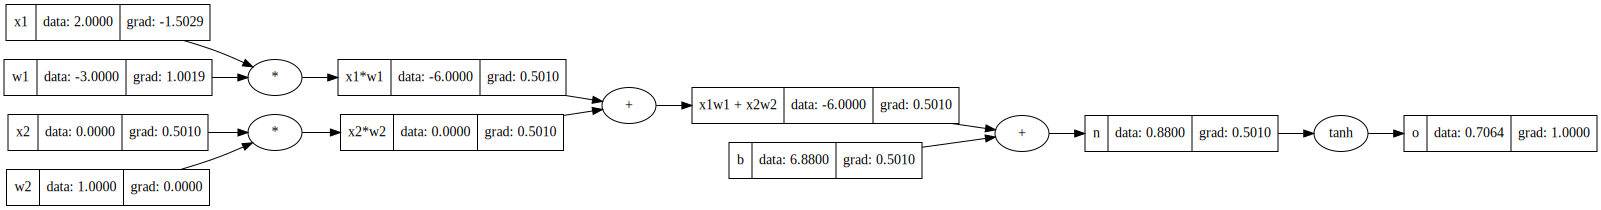

In [ ]:
# manually build what one neuron does: tanh(x1*w1 + x2*w2 + b)
# this is the same math your Neuron class does, just written out step by step
# so the graph is easy to read

x1 = Value(2.0,  label='x1')   # input 1
x2 = Value(0.0,  label='x2')   # input 2
w1 = Value(-3.0, label='w1')   # weight 1
w2 = Value(1.0,  label='w2')   # weight 2
b  = Value(6.88, label='b')    # bias (picked so tanh output is ~0)

# weighted sum: x1*w1 + x2*w2 + b
x1w1      = x1 * w1;        x1w1.label = 'x1*w1'
x2w2      = x2 * w2;        x2w2.label = 'x2*w2'
x1w1x2w2  = x1w1 + x2w2;   x1w1x2w2.label = 'x1w1 + x2w2'
n         = x1w1x2w2 + b;   n.label = 'n'

# activation
o = n.tanh();  o.label = 'o'

# run backward so every grad gets filled in
o.backward()

# draw the full computation graph
draw_dot(o)

ACTUAL NEURAL NETWORK

In [ ]:
#NEURON

import random

class Neuron:
  """
  One single neuron. Like one tiny decison - maker.

  It takes a list of inputs, multiplies each of them by a weight,
  adds a bias, then squshes through tanh.

  Example: a neuron with 3 inputs has 3 weights and 1 bias. = 4 parameters.
  """

  def __init__(self, nin):
    """

    nin : number of inputs this neuron recieves

    initialize weights randomly between -1 and 1.
    why random: if all weights start at 0, every neuron learns the same thing
    each input gets its own weight: "How much do I care for this input?"

    """
    self.w = [Value(random.uniform(-1, 1)) for _ in range(nin)]

    #one bias. This is like a "default lean" - even if all inputs are ,
    # the bias lets the neuron still fire a non-zero output.
    self.b = Value(random.uniform(-1, 1))


  def __call__(self, x):
    """
    Run the neuron on inputs x.

    step 1: Weighted sum = w1*x1 + w2*x2 + ... + wn*xn + b
    step 2: apply tanh to squish the result

    """

    #zip (self.w, x) pairs each weight with its corresponding input
    # wi * xi computes the weighted contribution of each input

    #sum(..., self.b) adds them all up, starting from the bias
    act = self.b
    for wi, xi in zip(self.w, x):
      act = act + wi * xi

    out = act.tanh()
    return out

  def parameters(self):
    return self.w + [self.b]







In [ ]:
#LAYER

class Layer:
  """
  A layer is just a bunch of neuron sitting side by side.

  All neurons in a layer recieve the SAME inputs,
  but each has its own weights and produce its own output.

  If you have 4 neurons in a layer, you get 4 outputs.

  """

  def __init__(self, nin, nout):
    """
    nin : number of inputs
    nout : number of neurons in this layer
    """
    self.neurons = [Neuron(nin) for _ in range(nout)]


  def __call__(self, x):
    #Run every neuron on the input x, collect all their outputs
    outs = [n(x) for n in self.neurons]

    #If only one neuron , return the value directly (not a list)
    #this makes the output layer cleaner for single output problems

    return outs[0] if len(outs) == 1 else outs

  def parameters(self):
    #collect parameters from ALL neurons in this layer

    return [p for neuron in self.neurons for p in neuron.parameters()]


In [ ]:
# Multi layer perceptron

class MLP:
  """
  MLP = Multi Layer Perceptron. This is a feedforward neural network.

  You give it:
  - nin : number of inputs
  -nouts : a list of number of neurons per layer

  Example: MLP(3, [4, 4, 1])
  - 3 inputs
  - 4 neurons in the first layer
  - 4 neurons in the second layer
  - 1 output
  """

  def __init__(self, nin, nouts):
    #Build the size of each connecntion:
    # [nin, nouts[0], nouts[1], ..., nouts[-1]]
    # e.g for MLP (3, [4,4,1]) -> [3, 4, 4 ,1]
    sz = [nin] + nouts

    #create layers. layer i connects sz[i] inputs to sz[i+1] outputs.
    #zip(sz, sz[1:]) pairs consecutive sizes: (3,4 ), (4,4), (4,1)
    self.layers = [Layer(sz[i], sz[i+1]) for i in range(len(nouts))]

  def __call__(self, x):
        # Forward pass: feed x through each layer in sequence
        # The output of one layer becomes the input to the next
        for layer in self.layers:
            x = layer(x)
        return x

  def parameters(self):
        # Collect ALL parameters from ALL layers
        return [p for layer in self.layers for p in layer.parameters()]

step 0: loss = 5.7869
step 1: loss = 2.1675
step 2: loss = 0.5471
step 3: loss = 0.2738
step 4: loss = 0.1990
step 5: loss = 0.1545
step 6: loss = 0.1251
step 7: loss = 0.1045
step 8: loss = 0.0894
step 9: loss = 0.0778
step 10: loss = 0.0687
step 11: loss = 0.0613
step 12: loss = 0.0553
step 13: loss = 0.0503
step 14: loss = 0.0461
step 15: loss = 0.0425
step 16: loss = 0.0394
step 17: loss = 0.0367
step 18: loss = 0.0343
step 19: loss = 0.0322


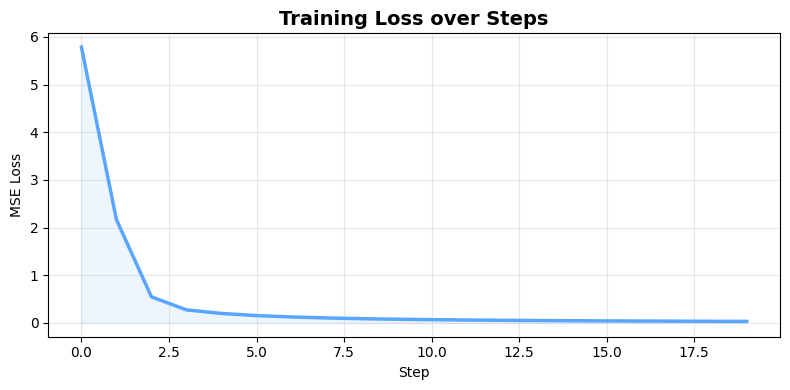

In [ ]:
import matplotlib.pyplot as plt

losses = []  # collect loss at every step

n = MLP(3, [4, 4, 1])

for k in range(20):

    # ---- FORWARD PASS ----
    # run every input through the network and get predictions
    ypred = [n(x) for x in xs]

    # ---- COMPUTE LOSS ----
    # Mean Squared Error: average of (prediction - truth)^2
    # if our predictions are perfect, loss = 0
    # the bigger the mistakes, the bigger the loss
    loss = sum((yout - ygt)**2 for ygt, yout in zip(ys, ypred))

    # ---- ZERO GRADIENTS ----
    # before backprop, reset all gradients to 0.
    # why? because _backward() uses +=, so old gradients would accumulate.
    # always zero before each backward pass!
    for p in n.parameters():
        p.grad = 0.0

    # ---- BACKWARD PASS ----
    # compute gradients: how does each weight affect the loss?
    loss.backward()

    # ---- UPDATE WEIGHTS (Gradient Descent) ----
    # move each weight slightly in the direction that reduces loss.
    # grad > 0 means "increasing this weight increases loss" → decrease it
    # grad < 0 means "increasing this weight decreases loss" → increase it
    # 0.05 is the "learning rate" — how big of a step we take
    for p in n.parameters():
        p.data += -0.05 * p.grad

    losses.append(loss.data)  # save loss for plotting
    print(f"step {k}: loss = {loss.data:.4f}")

# ---- PLOT ----
plt.figure(figsize=(8, 4))
plt.plot(losses, color='#58a6ff', linewidth=2.5)
plt.fill_between(range(len(losses)), losses, alpha=0.1, color='#58a6ff')
plt.title("Training Loss over Steps", fontsize=14, fontweight='bold')
plt.xlabel("Step")
plt.ylabel("MSE Loss")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

       MODEL CONFIGURATION
  Architecture      : MLP(3 → 4 → 4 → 1)
  Total layers      : 3
  Total parameters  : 41
  Learning rate     : 0.05
  Training steps    : 20
  Loss function     : Mean Squared Error
  Activation        : tanh
  Layer 1  →  4 neurons  ×  3 weights  +  1 bias  =  4 params each
  Layer 2  →  4 neurons  ×  4 weights  +  1 bias  =  5 params each
  Layer 3  →  1 neurons  ×  4 weights  +  1 bias  =  5 params each

       FINAL PREDICTIONS
  Input                  Target     Predicted    Correct?
  ----------------------------------------------
  [2.0, 3.0, -1.0]         1.0       0.9139         ✓
  [3.0, -1.0, 0.5]        -1.0      -0.9362         ✓
  [0.5, 1.0, 1.0]         -1.0      -0.9012         ✓
  [1.0, 1.0, -1.0]         1.0       0.9048         ✓
  ----------------------------------------------
  Accuracy: 4/4 = 100%


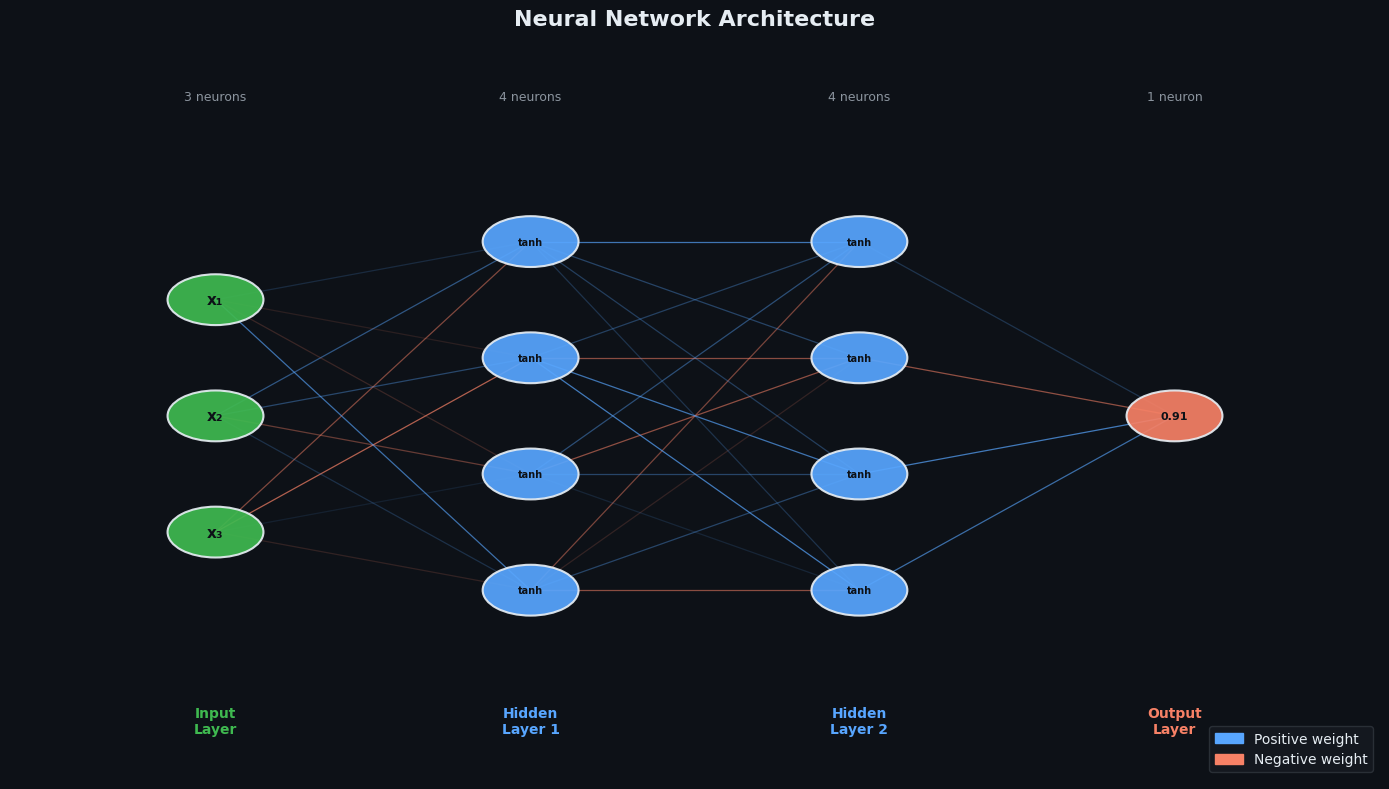

In [ ]:

# FINAL SUMMARY — configurations, predictions, and network visual


import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyArrowPatch

# ---- 1. CONFIGURATIONS ----
print("=" * 50)
print("       MODEL CONFIGURATION")
print("=" * 50)
print(f"  Architecture      : MLP(3 → 4 → 4 → 1)")
print(f"  Total layers      : {len(n.layers)}")
print(f"  Total parameters  : {len(n.parameters())}")
print(f"  Learning rate     : 0.05")
print(f"  Training steps    : 20")
print(f"  Loss function     : Mean Squared Error")
print(f"  Activation        : tanh")
print("=" * 50)

for i, layer in enumerate(n.layers):
    print(f"  Layer {i+1}  →  {len(layer.neurons)} neurons  ×  {len(layer.neurons[0].w)} weights  +  1 bias  =  {len(layer.neurons[0].w) + 1} params each")

print("=" * 50)

# ---- 2. FINAL PREDICTIONS ----
print("\n" + "=" * 50)
print("       FINAL PREDICTIONS")
print("=" * 50)
print(f"  {'Input':<20} {'Target':>8}  {'Predicted':>12}  {'Correct?':>10}")
print("  " + "-" * 46)

ypred = [n(x) for x in xs]
correct = 0
for x, ygt, yout in zip(xs, ys, ypred):
    pred_val = yout.data
    predicted_label = 1.0 if pred_val > 0 else -1.0
    ok = "✓" if predicted_label == ygt else "✗"
    if predicted_label == ygt:
        correct += 1
    print(f"  {str(x):<20}  {ygt:>6.1f}   {pred_val:>10.4f}  {ok:>8}")

print("  " + "-" * 46)
print(f"  Accuracy: {correct}/{len(xs)} = {correct/len(xs)*100:.0f}%")
print("=" * 50)

# ---- 3. NEURAL NETWORK VISUALIZATION ----
fig, ax = plt.subplots(figsize=(14, 8))
ax.set_facecolor('#0d1117')
fig.patch.set_facecolor('#0d1117')
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
ax.axis('off')
ax.set_title('Neural Network Architecture', color='#e6edf3',
             fontsize=16, fontweight='bold', pad=20)

# define layer positions (x) and neuron counts
layer_sizes = [3, 4, 4, 1]
layer_labels = ['Input\nLayer', 'Hidden\nLayer 1', 'Hidden\nLayer 2', 'Output\nLayer']
layer_colors = ['#3fb950', '#58a6ff', '#58a6ff', '#f78166']
x_positions = [1.5, 3.8, 6.2, 8.5]

# compute y positions for neurons in each layer so they're centered
def neuron_y_positions(n_neurons, y_center=5.0, spacing=1.6):
    total_height = (n_neurons - 1) * spacing
    start = y_center + total_height / 2
    return [start - i * spacing for i in range(n_neurons)]

neuron_positions = []
for size, xpos in zip(layer_sizes, x_positions):
    ys_pos = neuron_y_positions(size)
    neuron_positions.append([(xpos, y) for y in ys_pos])

# draw connections (weights) between layers — color by sign of weight
for layer_idx in range(len(layer_sizes) - 1):
    src_positions = neuron_positions[layer_idx]
    dst_positions = neuron_positions[layer_idx + 1]
    layer_obj = n.layers[layer_idx]

    for j, (dst_x, dst_y) in enumerate(dst_positions):
        neuron_obj = layer_obj.neurons[j]
        for i, (src_x, src_y) in enumerate(src_positions):
            w_val = neuron_obj.w[i].data
            # positive weight → blue, negative weight → red
            color = '#58a6ff' if w_val > 0 else '#f78166'
            alpha = min(abs(w_val), 1.0) * 0.6 + 0.1  # stronger weight = more visible
            ax.plot([src_x, dst_x], [src_y, dst_y],
                    color=color, alpha=alpha, linewidth=0.9, zorder=1)

# draw neurons as circles
neuron_radius = 0.35
for layer_idx, (positions, color) in enumerate(zip(neuron_positions, layer_colors)):
    for node_idx, (xpos, ypos) in enumerate(positions):
        circle = plt.Circle((xpos, ypos), neuron_radius,
                             color=color, zorder=3, linewidth=1.5,
                             ec='#e6edf3', alpha=0.92)
        ax.add_patch(circle)

        # label input neurons with feature names
        if layer_idx == 0:
            labels_in = ['x₁', 'x₂', 'x₃']
            ax.text(xpos, ypos, labels_in[node_idx],
                    ha='center', va='center', fontsize=11,
                    color='#0d1117', fontweight='bold', zorder=4)

        # label output neuron with its current value
        elif layer_idx == len(layer_sizes) - 1:
            out_val = ypred[0].data  # show prediction for first input
            ax.text(xpos, ypos, f'{out_val:.2f}',
                    ha='center', va='center', fontsize=8,
                    color='#0d1117', fontweight='bold', zorder=4)

        # label hidden neurons with tanh
        else:
            ax.text(xpos, ypos, 'tanh',
                    ha='center', va='center', fontsize=7,
                    color='#0d1117', fontweight='bold', zorder=4)

# draw layer labels at the bottom
for xpos, label, color in zip(x_positions, layer_labels, layer_colors):
    ax.text(xpos, 0.8, label, ha='center', va='center',
            fontsize=10, color=color, fontweight='bold')

# draw neuron count above each layer
for xpos, size in zip(x_positions, layer_sizes):
    ax.text(xpos, 9.4, f'{size} neuron{"s" if size > 1 else ""}',
            ha='center', va='center', fontsize=9, color='#8b949e')

# legend for connection colors
pos_patch = mpatches.Patch(color='#58a6ff', label='Positive weight')
neg_patch = mpatches.Patch(color='#f78166', label='Negative weight')
ax.legend(handles=[pos_patch, neg_patch], loc='lower right',
          facecolor='#161b22', edgecolor='#30363d',
          labelcolor='#e6edf3', fontsize=10)

plt.tight_layout()
plt.show()